[[0]
 [1]
 [2]
 [3]
 [4]
 [5]]
starting the inverse
0.0010411739349365234  seconds elapsed
origin | x: 0.0 | y: 0.0 | z: 0.0
outer_node_0 | x: 0.021012986154844183 | y: -0.001 | z: -0.001
strut_node_0 | x: -0.0007237541701090513 | y: 0.0043 | z: 0.0043
outer_node_1 | x: -0.0010320849144110909 | y: -0.0007 | z: -0.0007
strut_node_1 | x: -0.0031927540954294334 | y: 0.0012 | z: 0.0012
outer_node_2 | x: -0.0010482420657147529 | y: -0.0013 | z: -0.0013
strut_node_2 | x: -0.010392403704724967 | y: -0.0021 | z: -0.0021
outer_node_3 | x: 0.0004437349555858788 | y: -0.0015 | z: -0.0015
strut_node_3 | x: -0.004380245537268478 | y: -0.0074 | z: -0.0074
outer_node_4 | x: 0.001095452139002099 | y: 0.0006 | z: 0.0006
strut_node_4 | x: 0.0007908084014281325 | y: 0.0046 | z: 0.0046
outer_node_5 | x: -0.0007171405877665724 | y: 0.0008 | z: 0.0008
strut_node_5 | x: -0.004244529407226434 | y: 0.004 | z: 0.004
outer_node_6 | x: -0.0015360612476899669 | y: -0.0007 | z: -0.0007
strut_node_6 | x: -0.00880863

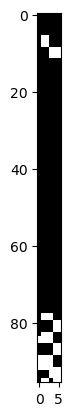

In [11]:
import math
import numpy as np
import matplotlib.pyplot as plt
from Scripts.drone import Drone
from Scripts.beams import BeamType
import Scripts.FEA_3D as FEA_3D

def plot_drone_geometry(drone,q):
    ax = plt.figure().add_subplot(projection='3d')
    ax.set_xlim([-0.5, 0.5])
    ax.set_ylim([-0.5, 0.5])
    ax.set_zlim([-0.5, 0.5])
    drone_geo = drone.beam_system
    ax.scatter(drone_geo.nodes[:,0] + drone_geo.x_displacements,
               drone_geo.nodes[:,1] + drone_geo.y_displacements, 
               drone_geo.nodes[:,2] + drone_geo.z_displacements)
    
    for beam in drone_geo.beams:
        '''
        node_0_x = beam.start_node_coords[0]
        node_1_x = beam.end_node_coords[0]
        node_0_y = beam.start_node_coords[1]
        node_1_y = beam.end_node_coords[1]
        node_0_z = beam.start_node_coords[2]
        node_1_z = beam.end_node_coords[2]
        
        X_len = node_1_x - node_0_x
        Y_len = node_1_y - node_0_y
        Z_len = node_1_z - node_0_z

        X = np.empty(q)
        Y = np.empty(q)
        Z = np.empty(q)
        for i in range(q):
            N_X = FEA_3D.shape_function(X_len * i / q, X_len)
            N_Y = FEA_3D.shape_function(Y_len * i / q, Y_len)
            N_Z = FEA_3D.shape_function(Z_len * i / q, Z_len)
            X[i] = node_0_x + N_X[0] * beam.x_displacement[0] + N_X[1] * beam.x_angles[0] + N_X[2] * beam.x_displacement[1] + N_X[3] * beam.x_angles[1]
            Y[i] = node_0_y + N_Y[0] * beam.y_displacement[0] + N_Y[1] * beam.y_angles[0] +  N_Y[2] * beam.y_displacement[1] + N_Y[3] * beam.y_angles[1]
            Z[i] = node_0_z + N_Z[0] * beam.z_displacement[0] + N_Z[1] * beam.z_angles[0] + N_Z[2] * beam.z_displacement[1] + N_Z[3] * beam.z_angles[1]
        '''
        ax.plot([beam.start_node_coords[0] + beam.x_displacement[0], beam.end_node_coords[0] + beam.x_displacement[1]],
                [beam.start_node_coords[1] + beam.y_displacement[0], beam.end_node_coords[1] + beam.y_displacement[1]],
                [beam.start_node_coords[2] + beam.z_displacement[0], beam.end_node_coords[2] + beam.z_displacement[1]])


d1 = Drone("drone_test")
arm_beam = BeamType("annulus", [0.025, 0.018], "Aluminum7075-T6", "arm_beam")
strut_beam = BeamType("annulus", [0.025, 0.018], "Aluminum7075-T6", "strut_beam")

d1.create_drone_nodes(0.5,0.2,8)           # nominal radius | strut rad | number of blades
# d1.rotate_drone_nodes(0,math.pi/5,math.pi/60)      # x-axis | y-axis | z-axis
d1.create_drone_beams(arm_beam,strut_beam) # arm beam | strut beam

d1.beam_system.add_force(0,0,-10,"outer_node_0")

d1.boundary_conditions()


#print(d1.beam_system.dp)
#print(np.shape(d1.beam_system.rp))
#print(np.shape(d1.beam_system.du))
#print(np.shape(d1.beam_system.dp))

d1.solve_fea()
#print(d1.beam_system.ru)
#print(d1.beam_system.rp)

#print(d1.beam_system.du)
#print(d1.beam_system.dp)

#plot_drone_geometry(d1,10)

for node_num, node in enumerate(d1.beam_system.node_names):
    print(node + 
          " | x: " + str(d1.beam_system.x_displacements[node_num]) + 
          " | y: " + str(round(d1.beam_system.y_displacements[node_num],4)) +
          " | z: " + str(round(d1.beam_system.y_displacements[node_num],4)))


#print(d1.beam_system.force_moment_vector)
#print(d1.beam_system.displacement_angle_vector)
#print(d1.beam_system.node_names) good
#print(d1.beam_system.force_node_indexes) good
#print(d1.beam_system.ru)
#print(d1.beam_system.displacement_angle_vector)
#print(d1.beam_system.kup)

plt.imshow(np.where(d1.beam_system.kup == 0, 0, 1), interpolation='none', cmap='gray')